### Контекст
Этот набор данных был получен из Национального института диабета, болезней органов пищеварения и почек. Цель использования данных — диагностическое прогнозирование наличия или отсутствия диабета у пациента на основе определенных диагностических показателей. При отборе этих записей из более обширной базы данных учитывался ряд ограничений. В частности, все представленные здесь пациентки — женщины в возрасте от 21 года, принадлежащие к индейскому племени пима.

### Содержание
Набор данных включает несколько медицинских переменных-предикторов и одну целевую переменную — Outcome (результат). К числу предикторов относятся количество беременностей, индекс массы тела (ИМТ), уровень инсулина, возраст и другие показатели.

In [1]:
import pandas as pd

from private import utils
from public import analyzer

data_frame : pd.DataFrame = utils.prepare_diabet_data()
analyzer.report(
    data_frame,
    [
        analyzer.dataset_stats_info,
        analyzer.duplicates_info,
        analyzer.missing_value_info,
        analyzer.not_numeric_columns_info,
        analyzer.anomalies_info
    ] 
)


total
	768

head
	   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
	0            6      148             72             35        0  33.6   
	1            1       85             66             29        0  26.6   
	2            8      183             64              0        0  23.3   
	3            1       89             66             23       94  28.1   
	4            0      137             40             35      168  43.1   

	   DiabetesPedigreeFunction  Age  Outcome  
	0                     0.627   50        1  
	1                     0.351   31        0  
	2                     0.672   32        1  
	3                     0.167   21        0  
	4                     2.288   33        1  

total duplicates
	0

duplicates
	None

columns with missed values
	Series([], dtype: int64)

columns with not numeric types


anomalies
	Not implemented yet


preprocessing took 0.000 seconds
training took 0.025 seconds
predict took 0.000 seconds
evaluate took 0.005 seconds
Коэффициенты линейной регрессии:
	[ 2.01842752e-02  5.51032049e-03 -1.95350127e-03 -4.74640473e-04
 -1.11329091e-04  1.46493962e-02  1.63125112e-01  1.54332578e-03]
Intercept:
	-0.8378252997490478
Среднеквадратичная ошибка:
	nan
Коэффициент детерминации R^2:
	0.29900077702631167
report took 0.000 seconds


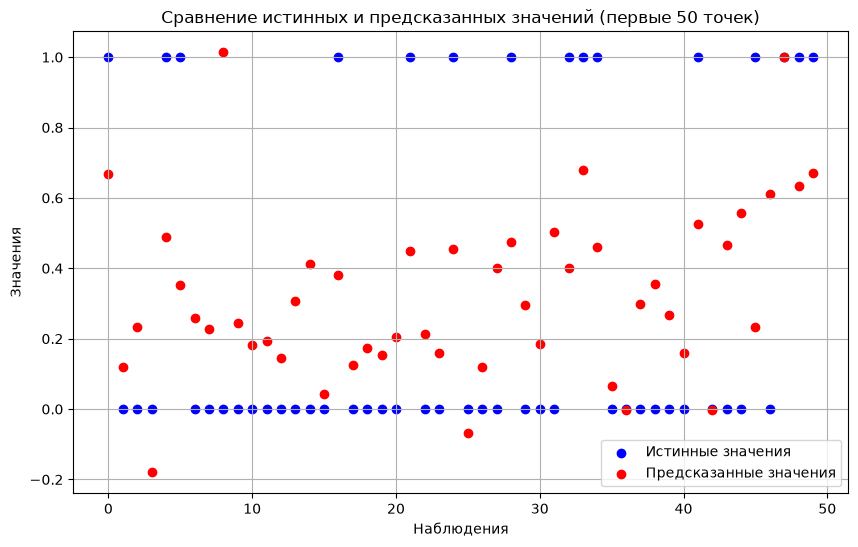

In [2]:
from public.model_for_linear_regresssion import LinearRegressionModel

model: LinearRegressionModel = (
        LinearRegressionModel(df=data_frame, target_column="Outcome", test_size=0.2)  # set datadrame
        .preprocessing(  # transmrm dataframe based on analizer info
            {}
        )
        .training()  # trainig
        .predict()  # predicttion based on test data
        .evaluate()  # evaluate model presicion
)
model.report()
model.draw()